In [19]:
import torch

from pprint import pprint

from decoder_patching import (
    decode_from_encoder_output,
    get_encoder_output,
    load_mask_predict_context,
    plot_token_mask_probs,
    run_decoder_patching_experiment,
)
from utils import REPO_ROOT, preprocess_mask_predict_data, trace_mask_predict_iterations

In [20]:
prep_result = preprocess_mask_predict_data(
    input_dir=REPO_ROOT / "input",
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    run_name="en_de_demo",
    workers=10,
)

In [21]:
trace_result = trace_mask_predict_iterations(
    data_bin_dir=prep_result["data_bin_dir"],
    output_dir=REPO_ROOT / "output",
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    subset="test",
    run_name="en_de_demo",
    decoding_iterations=5,
    length_beam=5,
    max_sentences=20,
)

for record in trace_result["records"]:
    print(f"[{record['id']}]")
    print("src:", record["source"])
    print("tgt:", record["target"])
    print("hyp:", record["hypothesis"])
    print("iterations:")
    for step in record["iterations"]:
        print(f"iter {step['iteration']:02d} (masked={step['masked_tokens']:>2}): {step['text']}")


[0]
src: The capital of France is Paris .
tgt: Die Hauptstadt Frankreichs ist Paris .
hyp: Die Hauptstadt Frankreichs ist Paris .
iterations:
iter 00 (masked= 0): Die Hauptstadt Frankreichs ist Paris .
iter 01 (masked= 5): Die Hauptstadt Frankreichs ist Paris .
iter 02 (masked= 4): Die Hauptstadt Frankreichs ist Paris .
iter 03 (masked= 2): Die Hauptstadt Frankreichs ist Paris .
iter 04 (masked= 1): Die Hauptstadt Frankreichs ist Paris .
[1]
src: The capital of Germany is Berlin .
tgt: Die Hauptstadt Deutschlands ist Berlin .
hyp: Die Hauptstadt Deutschlands ist Berlin .
iterations:
iter 00 (masked= 0): Die Hauptstadt Deutschlands ist Berlin .
iter 01 (masked= 5): Die Hauptstadt Deutschlands ist Berlin .
iter 02 (masked= 4): Die Hauptstadt Deutschlands ist Berlin .
iter 03 (masked= 2): Die Hauptstadt Deutschlands ist Berlin .
iter 04 (masked= 1): Die Hauptstadt Deutschlands ist Berlin .
[2]
src: China is a large country in Asia , and the capital of the country is Beijing .
tgt: China i

In [22]:
state = torch.load("./checkpoints/maskPredict_en_de/checkpoint_best.pt", map_location="cpu", weights_only=False)
model_args = state["args"]

for k in [
    "arch",
    "encoder_layers",
    "encoder_embed_dim",
    "encoder_ffn_embed_dim",
    "encoder_attention_heads",
    "decoder_layers",
    "decoder_embed_dim",
    "decoder_ffn_embed_dim",
    "decoder_attention_heads",
]:
    if hasattr(model_args, k):
        print(k, "=", getattr(model_args, k))


arch = bert_transformer_seq2seq
encoder_layers = 6
encoder_embed_dim = 512
encoder_ffn_embed_dim = 2048
encoder_attention_heads = 8
decoder_layers = 6
decoder_embed_dim = 512
decoder_ffn_embed_dim = 2048
decoder_attention_heads = 8


In [23]:
context = load_mask_predict_context(
    data_bin_dir=prep_result["data_bin_dir"],
    model_dir=REPO_ROOT / "checkpoints" / "maskPredict_en_de",
    source_lang="en",
    target_lang="de",
    decoding_iterations=5,
    length_beam=5,
    max_sentences=20,
    use_cpu=True,
)

In [24]:
encoder_example = get_encoder_output(
    "China is a large country in Asia , and the capital of the country is Beijing .",
    context,
)

print("sentence:", encoder_example["sentence"])
print("src_tokens shape:", tuple(encoder_example["src_tokens"].shape))
print("src_lengths:", encoder_example["src_lengths"].tolist())
print("predicted target length:", int(encoder_example["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

sentence: China is a large country in Asia , and the capital of the country is Beijing .
src_tokens shape: (1, 18)
src_lengths: [18]
predicted target length: 16


In [35]:
patch_src_sentence = "The organ was tuned before the concert ."
patch_tgt_sentence = "The organ was damaged in the accident ."

patch_src = get_encoder_output(patch_src_sentence, context)
patch_tgt = get_encoder_output(patch_tgt_sentence, context)

In [45]:
print("patch source sentence:", patch_src["sentence"])
print("patch target sentence:", patch_tgt["sentence"])
print("patch source encoder_out shape:", tuple(patch_src["encoder_out"]["encoder_out"].shape))
print("patch target encoder_out shape:", tuple(patch_tgt["encoder_out"]["encoder_out"].shape))
print("patch source token ids:", patch_src["src_tokens"].tolist())
print("patch target token ids:", patch_tgt["src_tokens"].tolist())
print("patch source predicted target length:", int(patch_src["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))
print("patch target predicted target length:", int(patch_tgt["encoder_out"]["predicted_lengths"].argmax(dim=-1).item()))

patch source sentence: The organ was tuned before the concert .
patch target sentence: The organ was damaged in the accident .
patch source encoder_out shape: (9, 1, 512)
patch target encoder_out shape: (9, 1, 512)
patch source token ids: [[30, 17638, 66, 3, 494, 7, 11752, 6, 2]]
patch target token ids: [[30, 17638, 66, 16532, 8, 7, 11138, 6, 2]]
patch source predicted target length: 10
patch target predicted target length: 8


In [46]:
layer_index = 3
token_position = 3

print("decoder layer index:", layer_index)
print("decoder token position:", token_position)
print("donor source token id at aligned source position:", patch_src["src_tokens"][0, token_position].item())
print("base source token id at aligned source position:", patch_tgt["src_tokens"][0, token_position].item())

decoder layer index: 3
decoder token position: 3
donor source token id at aligned source position: 3
base source token id at aligned source position: 16532


In [38]:
decoded_original_tgt = decode_from_encoder_output(
    patch_tgt["encoder_out"],
    context=context,
    decoding_iterations=5,
)

decoder_patch_result = run_decoder_patching_experiment(
    donor_sentence=patch_src_sentence,
    base_sentence=patch_tgt_sentence,
    context=context,
    layer_index=layer_index,
    token_position=token_position,
    decoding_iterations=5,
)

In [39]:
print("source sentence:", patch_src_sentence)
print("target sentence:", patch_tgt_sentence)
print("decoded from original target encoder:", decoded_original_tgt["decoded_text"])
print("decoded from decoder-patched target:", decoder_patch_result["decoded_text"])
print()
print("patched decoder iteration trace:")
for step in decoder_patch_result["iteration_trace"]:
    print(f"iter {step['iteration']:02d}: {step['text']}")
    print("  selected mask tokens:", step["selected_mask_tokens"])
    print("  selected mask probs:", step["selected_mask_probs"])
    print("  token mask probs:", step["token_mask_probs"])

source sentence: The organ was tuned before the concert .
target sentence: The organ was damaged in the accident .
decoded from original target encoder: Das Organ wurde beim Unfall beschädigt .
decoded from decoder-patched target: Das Organ wurde wurde Unfall beschädigt .

patched decoder iteration trace:
iter 00: Das Organ wurde wurde Unfall beschädigt .
  selected mask tokens: []
  selected mask probs: []
  token mask probs: [0.117465, 0.304341, 0.112623, 0.39751, 0.099913, 0.087079, 0.10027, 0.093012]
iter 01: Das Organ wurde wurde Unfall beschädigt .
  selected mask tokens: ['wurde', 'Organ', 'Das', 'wurde', '.', 'Unfall']
  selected mask probs: [0.39751, 0.304341, 0.117465, 0.112623, 0.10027, 0.099913]
  token mask probs: [0.116036, 0.285169, 0.109914, 0.120252, 0.09792, 0.087079, 0.100397, 0.093012]
iter 02: Das Organ wurde wurde Unfall beschädigt .
  selected mask tokens: ['Organ', 'wurde', 'Das', 'wurde']
  selected mask probs: [0.285169, 0.120252, 0.116036, 0.109914]
  token m

In [40]:
print("decoder patch activation trace:")
for step in decoder_patch_result["patch_trace"]:
    print(f"iter {step['iteration']:02d}:")
    print("  donor text:", step["donor_text"])
    print("  patched text:", step["patched_text"])
    print("  donor activation norm:", step["donor_activation_norm"])
    print("  base activation norm before patch:", step["base_activation_norm_before_patch"])
    print("  base activation norm after patch:", step["base_activation_norm_after_patch"])

decoder patch activation trace:
iter 00:
  donor text: Die Orgel war <<unk>> dem Konzert Konzert .
  patched text: Das Organ wurde wurde Unfall beschädigt .
  donor activation norm: 12.0423
  base activation norm before patch: 12.832011
  base activation norm after patch: 12.0423
iter 01:
  donor text: Die Orgel war <<unk>> dem Konzert Konzert .
  patched text: Das Organ wurde wurde Unfall beschädigt .
  donor activation norm: 11.641113
  base activation norm before patch: 12.677726
  base activation norm after patch: 11.641113
iter 02:
  donor text: Die Orgel war <<unk>> dem Konzert Konzert .
  patched text: Das Organ wurde wurde Unfall beschädigt .
  donor activation norm: 11.64584
  base activation norm before patch: 11.817572
  base activation norm after patch: 11.64584
iter 03:
  donor text: Die Orgel war vor dem Konzert <<unk>> .
  patched text: Das Organ wurde wurde Unfall beschädigt .
  donor activation norm: 11.470884
  base activation norm before patch: 11.773875
  base activ

In [41]:
final_predicted_sentence = decoder_patch_result["decoded_text"]
print("final predicted sentence:", final_predicted_sentence)

final predicted sentence: Das Organ wurde wurde Unfall beschädigt .


In [42]:
pprint(decoder_patch_result["patch_trace"][-1])

{'base_activation_norm_after_patch': 11.346056,
 'base_activation_norm_before_patch': 11.754251,
 'donor_activation_norm': 11.346056,
 'donor_text': 'Die Orgel war vor dem Konzert <<unk>> .',
 'iteration': 4,
 'patched_text': 'Das Organ wurde wurde Unfall beschädigt .'}


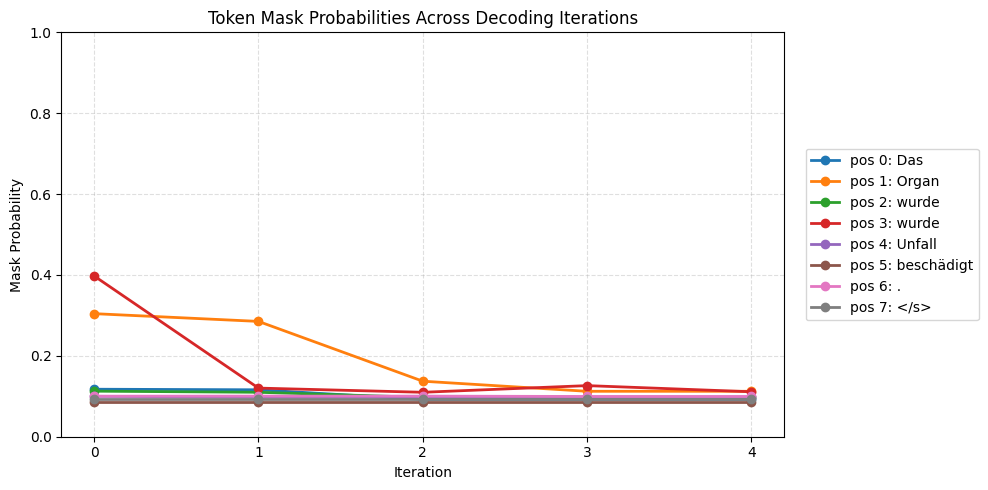

In [43]:
plot_token_mask_probs(decoder_patch_result)

In [44]:
print("final iteration mask probabilities:", decoder_patch_result["iteration_trace"][-1]["token_mask_probs"])


final iteration mask probabilities: [0.092113, 0.112355, 0.097337, 0.111159, 0.09792, 0.087079, 0.099535, 0.093012]
